# P3 - GMM + BIC Validation of Saved CNN Features

This notebook is independent of both the CNN execution and the Elbow notebook. It reads the same saved CNN features and applies the same standardisation/PCA recipe before selecting a Gaussian mixture model by the lowest BIC.

Both original and orientation-averaged representations are evaluated. No molecular labels or target of five components are supplied. A Gaussian component is a statistical density component, not automatically a chemical species. These are exploratory internal diagnostics, not measured classification accuracy.


## 1. Read saved CNN features and verify provenance

PyTorch, model weights and CNN execution are not required here. Missing or stale P2 outputs trigger an error. The output folder belongs only to GMM + BIC.


In [1]:
from pathlib import Path
import hashlib
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from IPython.display import display
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from threadpoolctl import threadpool_limits

%matplotlib inline

SEED = 42
PCA_VARIANCE = 0.95
K_MAX = 10

def locate_package(start=None):
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    for candidate in (start,*start.parents):
        if (candidate/"Project_Data").is_dir() and (candidate/"Notebooks").is_dir():
            return candidate
    raise FileNotFoundError("Start Jupyter inside the extracted share package.")

def sha256(path):
    h = hashlib.sha256()
    with path.open("rb") as stream:
        for block in iter(lambda:stream.read(1024*1024),b""):
            h.update(block)
    return h.hexdigest()

ROOT = locate_package()
FEATURE_DIR = ROOT/"Notebooks/P2/outputs/alternative1_cnn_features"
P1_DIR = ROOT/"Notebooks/P1/outputs/alternative_1_plane_fitting"
OUT = ROOT/"Notebooks/P3/outputs/cnn_gmm_bic"
OUT.mkdir(parents=True,exist_ok=True)

def relative(path):
    return path.relative_to(ROOT).as_posix()

manifest_path = FEATURE_DIR/"feature_manifest.json"
if not manifest_path.is_file():
    raise FileNotFoundError("Run the P2 CNN Feature Extraction notebook first.")
feature_manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
assert feature_manifest["schema_version"] == 1
assert feature_manifest["stage"] == "cnn_feature_extraction_only"
feature_artifacts = [
    "original_cnn_features.npy","orientation_average_cnn_features.npy",
    "patch_index.csv","candidate_metadata.csv","patches_gray.npy",
    "patches_height_m.npy","patch_masks.npy",
]
feature_hashes = {}
for name in feature_artifacts:
    path = FEATURE_DIR/name
    if not path.is_file():
        raise FileNotFoundError(f"Missing P2 artifact: {name}")
    feature_hashes[name] = sha256(path)
    if feature_hashes[name] != feature_manifest["artifact_hashes"][name]:
        raise ValueError(f"P2 artifact checksum mismatch: {name}. Rerun P2.")
for name,digest in feature_manifest["input_hashes"].items():
    path = P1_DIR/name
    if not path.is_file() or sha256(path)!=digest:
        raise ValueError(f"P1 changed after feature extraction: {name}. Rerun P2.")
manifest_hash = sha256(manifest_path)
patch_index = pd.read_csv(FEATURE_DIR/"patch_index.csv")
objects = pd.read_csv(FEATURE_DIR/"candidate_metadata.csv")
ids = patch_index.object_id.to_numpy(dtype=int)
assert patch_index.object_id.is_unique and objects.object_id.is_unique
assert np.array_equal(ids,objects.object_id.to_numpy())
assert len(ids)==feature_manifest["candidate_count"]
if len(ids)<4:
    raise ValueError("At least four candidates are required for these validation experiments.")
height = np.load(P1_DIR/"corrected_height.npy")
labels = np.load(P1_DIR/"label_image.npy")
patches = np.load(FEATURE_DIR/"patches_gray.npy")
assert height.shape == labels.shape and np.isfinite(height).all()
assert np.array_equal(ids,np.unique(labels[labels>0]))
assert patches.shape[0]==len(ids)
feature_sets = {name:np.load(FEATURE_DIR/f"{name}_cnn_features.npy")
                for name in ["original","orientation_average"]}
for features in feature_sets.values():
    assert features.shape==(len(ids),512) and np.isfinite(features).all()
print("Read-only CNN input:",relative(FEATURE_DIR))
print("Validation output:",relative(OUT))
print("Candidates:",len(ids))

from sklearn.mixture import GaussianMixture
GMM_N_INIT = 10
GMM_MAX_ITER = 500
REG_COVAR = 1e-5
COVARIANCE_TYPES = ("diag","tied","spherical")
METHOD_LABEL = "CNN + GMM + BIC"
METHOD_CONFIGURATION = {"n_init":GMM_N_INIT,"max_iter":GMM_MAX_ITER,
                        "reg_covar":REG_COVAR,"covariance_types":list(COVARIANCE_TYPES),
                        "selection":"lowest BIC among converged finite fits"}


Read-only CNN input: Notebooks/P2/outputs/alternative1_cnn_features
Validation output: Notebooks/P3/outputs/cnn_gmm_bic
Candidates: 248


## 2. Identical feature preparation for the two validation methods

Remove constant dimensions, apply StandardScaler, then PCA retaining at least 95% of variance using full SVD without whitening. This source cell is identical in both validation notebooks. Each representation has its own fitted transformation, but both algorithms receive the same transformed matrix for that representation.

This is exploratory analysis of the current scan, not a held-out accuracy test. PCA is fitted here, not in the CNN extractor. Comparing BIC across different representations or different PCA dimensions is not valid; compare it only among models fitted to the same matrix.


In [2]:
representations, transforms, preparation_rows = {}, {}, []
for name,features in feature_sets.items():
    keep = np.std(features,axis=0)>1e-12
    if keep.sum()<1:
        raise ValueError(f"No nonconstant features: {name}")
    scaler = StandardScaler()
    standardised = scaler.fit_transform(features[:,keep])
    pca = PCA(n_components=PCA_VARIANCE,svd_solver="full",whiten=False)
    matrix = pca.fit_transform(standardised)
    assert np.isfinite(matrix).all()
    representations[name] = matrix
    transforms[name] = {
        "retained_columns":np.flatnonzero(keep),
        "scaler_mean":scaler.mean_,"scaler_scale":scaler.scale_,
        "pca_mean":pca.mean_,"pca_components":pca.components_,
        "explained_variance_ratio":pca.explained_variance_ratio_,
    }
    np.save(OUT/f"{name}_pca_features.npy",matrix)
    preparation_rows.append({"representation":name,"retained_cnn_dimensions":int(keep.sum()),
                             "pca_dimensions":matrix.shape[1],
                             "retained_variance":float(pca.explained_variance_ratio_.sum())})
preparation = pd.DataFrame(preparation_rows)
preparation.to_csv(OUT/"feature_preparation.csv",index=False)
display(preparation)


,representation,retained_cnn_dimensions,pca_dimensions,retained_variance
0,original,512,39,0.950535
1,orientation_average,512,15,0.953332


## 3. Fit candidate mixtures and select the lowest BIC

Search component counts from 1 to 10 (subject to sample availability), and compare diagonal, tied and spherical covariance structures. No final count is fixed. Fully separate full-covariance matrices are omitted in this first small-sample experiment: with many PCA dimensions and 248 candidates, they add substantial flexibility. This is a declared model-family choice, not a guarantee of optimality.

Use ten initialisations per candidate, covariance regularisation and a convergence check. Select the lowest BIC only among finite, converged fits. Save the complete search table, including failed/nonconverged candidates. AIC is recorded for context, not used to select the winner. Minimum BIC at the search upper boundary is explicitly flagged.

The final model is the exact selected fitted model, not a new refit. Every object is assigned to its highest-probability component. Component count and nonempty hard-assignment group count are recorded separately, since some components may receive no winning assignments. Posterior probabilities describe this fitted mixture; they are not probabilities that a chemical label is correct.

BIC values are comparable only for models fitted to the same input matrix. Do not compare the absolute BIC of original and orientation-averaged representations to select a representation.


original : selected components = 10 , occupied groups = 10 , covariance = diag
CAUTION: minimum BIC is at the search upper limit; it is not a confirmed optimum.


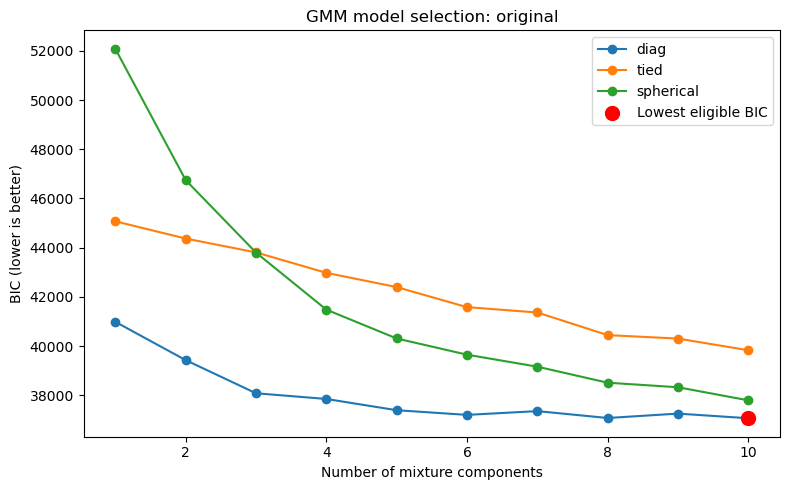

,n_components,covariance_type,bic,aic,eligible,status,iterations,warning_count,parameter_count
9,10,diag,37065.356999,34293.261719,True,converged,6,0,789
7,8,diag,37075.379789,34858.406250,True,converged,10,0,631
5,6,diag,37202.320547,35540.468750,True,converged,3,0,473
8,9,diag,37254.475816,34759.941406,True,converged,5,0,710
6,7,diag,37355.092355,35415.679688,True,converged,8,0,552
4,5,diag,37392.353426,36008.062500,True,converged,11,0,394
29,10,spherical,37793.113451,36356.121094,True,converged,4,0,409
3,4,diag,37848.980055,36742.250000,True,converged,6,0,315


,cluster_id,cluster_label,candidate_count
0,1,C1,49
1,2,C2,50
2,3,C3,36
3,4,C4,23
4,5,C5,47
5,6,C6,3
6,7,C7,23
7,8,C8,9
8,9,C9,7
9,10,C10,1


orientation_average : selected components = 10 , occupied groups = 10 , covariance = tied
CAUTION: minimum BIC is at the search upper limit; it is not a confirmed optimum.


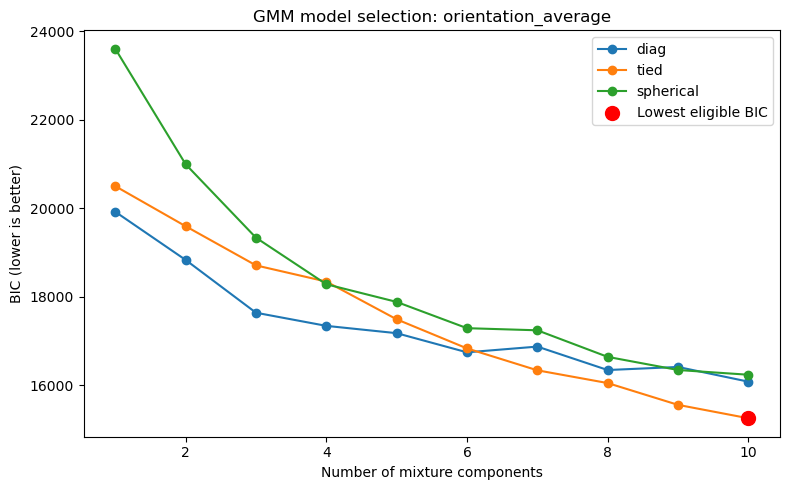

,n_components,covariance_type,bic,aic,eligible,status,iterations,warning_count,parameter_count
19,10,tied,15254.980995,14274.734375,True,converged,5,0,279
18,9,tied,15557.429221,14633.397461,True,converged,3,0,263
17,8,tied,16049.783697,15181.966797,True,converged,5,0,247
9,10,diag,16081.427803,14995.778320,True,converged,11,0,309
29,10,spherical,16237.763599,15643.994141,True,converged,16,0,169
16,7,tied,16337.917470,15526.315430,True,converged,2,0,231
7,8,diag,16344.197760,15476.380859,True,converged,6,0,247
28,9,spherical,16345.054841,15811.013672,True,converged,6,0,152


,cluster_id,cluster_label,candidate_count
0,1,C1,99
1,2,C2,23
2,3,C3,28
3,4,C4,55
4,5,C5,4
5,6,C6,10
6,7,C7,6
7,8,C8,9
8,9,C9,7
9,10,C10,7


,representation,candidate_count,pca_dimensions,selected_components,nonempty_groups,covariance_type,bic,aic,silhouette,at_search_upper_limit,near_best_models_delta_bic_under_2
0,original,248,39,10,10,diag,37065.356999,34293.261719,0.277762,True,1
1,orientation_average,248,15,10,10,tied,15254.980995,14274.734375,0.515110,True,1


In [3]:
from sklearn.exceptions import ConvergenceWarning

def parameter_count(k, d, covariance_type):
    covariance_parameters = {"diag": k*d, "tied": d*(d+1)//2, "spherical": k}[covariance_type]
    return (k-1) + k*d + covariance_parameters

results, metrics_rows = {}, []
for name,matrix in representations.items():
    max_k = min(K_MAX,len(ids)-1,len(np.unique(matrix,axis=0)))
    fitted_models, rows = {}, []
    with threadpool_limits(limits=1):
        for covariance_type in COVARIANCE_TYPES:
            for components in range(1,max_k+1):
                fitted = GaussianMixture(
                    n_components=components,covariance_type=covariance_type,
                    n_init=GMM_N_INIT,max_iter=GMM_MAX_ITER,reg_covar=REG_COVAR,
                    random_state=SEED,
                )
                try:
                    with warnings.catch_warnings(record=True) as caught:
                        warnings.simplefilter("always",ConvergenceWarning)
                        fitted.fit(matrix)
                    bic = float(fitted.bic(matrix))
                    aic = float(fitted.aic(matrix))
                    eligible = bool(fitted.converged_ and np.isfinite([bic,aic]).all())
                    status = "converged" if eligible else "not_eligible"
                    if eligible:
                        fitted_models[(components,covariance_type)] = fitted
                    rows.append({"n_components":components,"covariance_type":covariance_type,
                                 "bic":bic,"aic":aic,"eligible":eligible,"status":status,
                                 "iterations":int(fitted.n_iter_),"warning_count":len(caught),
                                 "parameter_count":parameter_count(components,matrix.shape[1],covariance_type)})
                except (ValueError,np.linalg.LinAlgError) as error:
                    rows.append({"n_components":components,"covariance_type":covariance_type,
                                 "bic":np.nan,"aic":np.nan,"eligible":False,
                                 "status":type(error).__name__,"iterations":0,"warning_count":0,
                                 "parameter_count":parameter_count(components,matrix.shape[1],covariance_type)})
    search = pd.DataFrame(rows)
    eligible = search.loc[search.eligible].sort_values(["bic","n_components","covariance_type"])
    if eligible.empty:
        search.to_csv(OUT/f"{name}_bic_search.csv",index=False)
        raise ValueError(f"No converged finite GMM candidates for {name}; inspect the search table.")
    best = eligible.iloc[0]
    selected = int(best.n_components)
    covariance = str(best.covariance_type)
    model = fitted_models[(selected,covariance)]
    search["selected"] = (search.n_components==selected) & (search.covariance_type==covariance)
    search["delta_bic"] = search.bic-float(best.bic)
    search.to_csv(OUT/f"{name}_bic_search.csv",index=False)
    assert np.isclose(model.bic(matrix),eligible.bic.min())
    posterior = model.predict_proba(matrix)
    raw_groups = model.predict(matrix)
    assert np.isfinite(posterior).all()
    np.testing.assert_allclose(posterior.sum(axis=1),1.0,rtol=1e-5)  # float32 posterior rounding
    active = np.unique(raw_groups)
    order = sorted(active,key=lambda c:objects.loc[raw_groups==c,"area_nm2"].mean())
    mapping = {int(raw):group for group,raw in enumerate(order,1)}
    groups = np.array([mapping[int(raw)] for raw in raw_groups])
    assignments = objects[["object_id","centroid_row","centroid_col"]].copy()
    assignments["cluster_id"] = groups
    assignments["cluster_label"] = [f"C{g}" for g in groups]
    assignments["raw_component_id"] = raw_groups
    assignments["max_component_probability"] = posterior.max(axis=1)
    counts = assignments.groupby(["cluster_id","cluster_label"]).size().reset_index(name="candidate_count")
    assignments.to_csv(OUT/f"{name}_assignments.csv",index=False)
    counts.to_csv(OUT/f"{name}_counts.csv",index=False)
    probability_table = pd.DataFrame(posterior,columns=[f"raw_component_{c}" for c in range(selected)])
    probability_table.insert(0,"object_id",ids)
    probability_table.to_csv(OUT/f"{name}_component_probabilities.csv",index=False)
    component_summary = pd.DataFrame([
        {"raw_component_id":c,"weight":float(model.weights_[c]),
         "assigned_candidates":int((raw_groups==c).sum()),
         "cluster_label":f"C{mapping[c]}" if c in mapping else "no_hard_assignments"}
        for c in range(selected)])
    component_summary.to_csv(OUT/f"{name}_component_summary.csv",index=False)
    np.savez_compressed(OUT/f"{name}_transform.npz",**transforms[name],
        gmm_weights=model.weights_,gmm_means=model.means_,gmm_covariances=model.covariances_,
        gmm_precisions_cholesky=model.precisions_cholesky_,
        covariance_type=np.array(covariance),
        raw_to_group=np.array([mapping.get(c,0) for c in range(selected)]))
    occupied = len(active)
    score = float(silhouette_score(matrix,raw_groups)) if 1<occupied<len(ids) else np.nan
    results[name] = {"k":occupied,"groups":groups,"assignments":assignments,"counts":counts}
    at_upper = selected==max_k
    metrics_rows.append({"representation":name,"candidate_count":len(ids),
                         "pca_dimensions":matrix.shape[1],"selected_components":selected,
                         "nonempty_groups":occupied,"covariance_type":covariance,
                         "bic":float(best.bic),"aic":float(best.aic),"silhouette":score,
                         "at_search_upper_limit":at_upper,
                         "near_best_models_delta_bic_under_2":int((eligible.bic-float(best.bic)<2).sum())})
    print(name,": selected components =",selected,", occupied groups =",occupied,", covariance =",covariance)
    if at_upper:
        print("CAUTION: minimum BIC is at the search upper limit; it is not a confirmed optimum.")
    if occupied!=selected:
        print("CAUTION: some mixture components have no highest-probability assignments.")
    fig,ax = plt.subplots(figsize=(8,5))
    for covariance_type in COVARIANCE_TYPES:
        table = search.loc[(search.covariance_type==covariance_type)&search.eligible]
        ax.plot(table.n_components,table.bic,"o-",label=covariance_type)
    ax.scatter([selected],[float(best.bic)],color="red",s=100,zorder=5,label="Lowest eligible BIC")
    ax.set(xlabel="Number of mixture components",ylabel="BIC (lower is better)",
           title=f"GMM model selection: {name}")
    ax.legend()
    fig.tight_layout()
    fig.savefig(OUT/f"{name}_bic.png",dpi=160)
    plt.show()
    display(eligible.head(8))
    display(counts)

metrics = pd.DataFrame(metrics_rows)
metrics.to_csv(OUT/"representation_comparison.csv",index=False)
display(metrics)


## 4. Inspect grouping maps and representative objects

Cluster labels C1, C2, ... are assigned by mean area for readability after fitting. Colours and numbers are local to each branch. The overlay preserves all P1 candidates, and each is counted once.

The scatter is a two-dimensional PCA projection; the model uses all retained components. Representative patches are nearest the mean of their hard-assigned group in PCA space, not manually chosen examples and not necessarily nearest by GMM Mahalanobis distance.


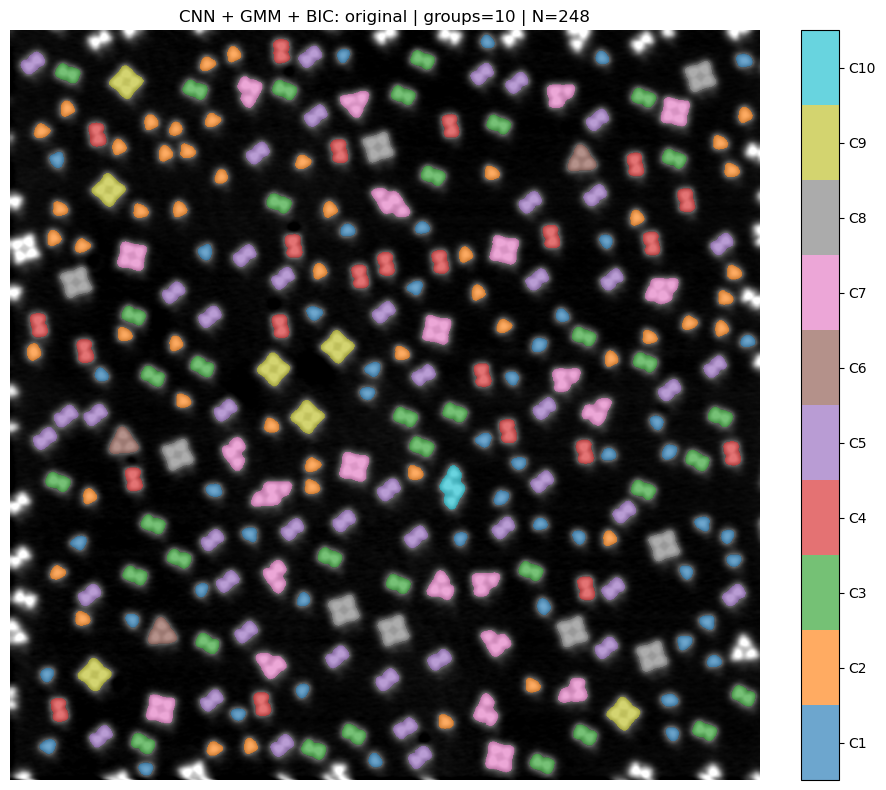

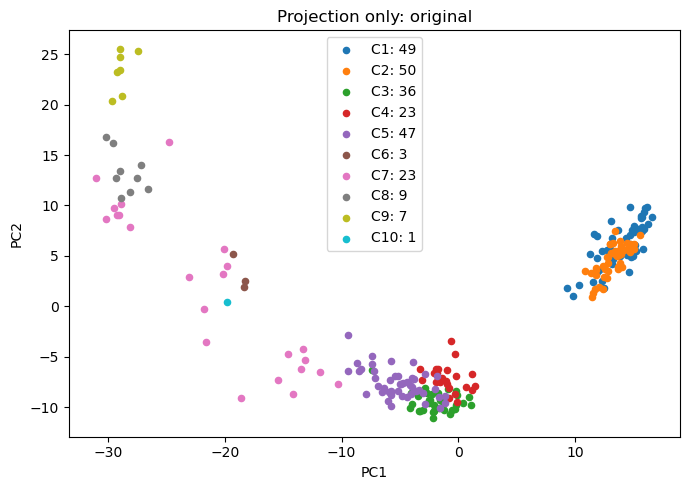

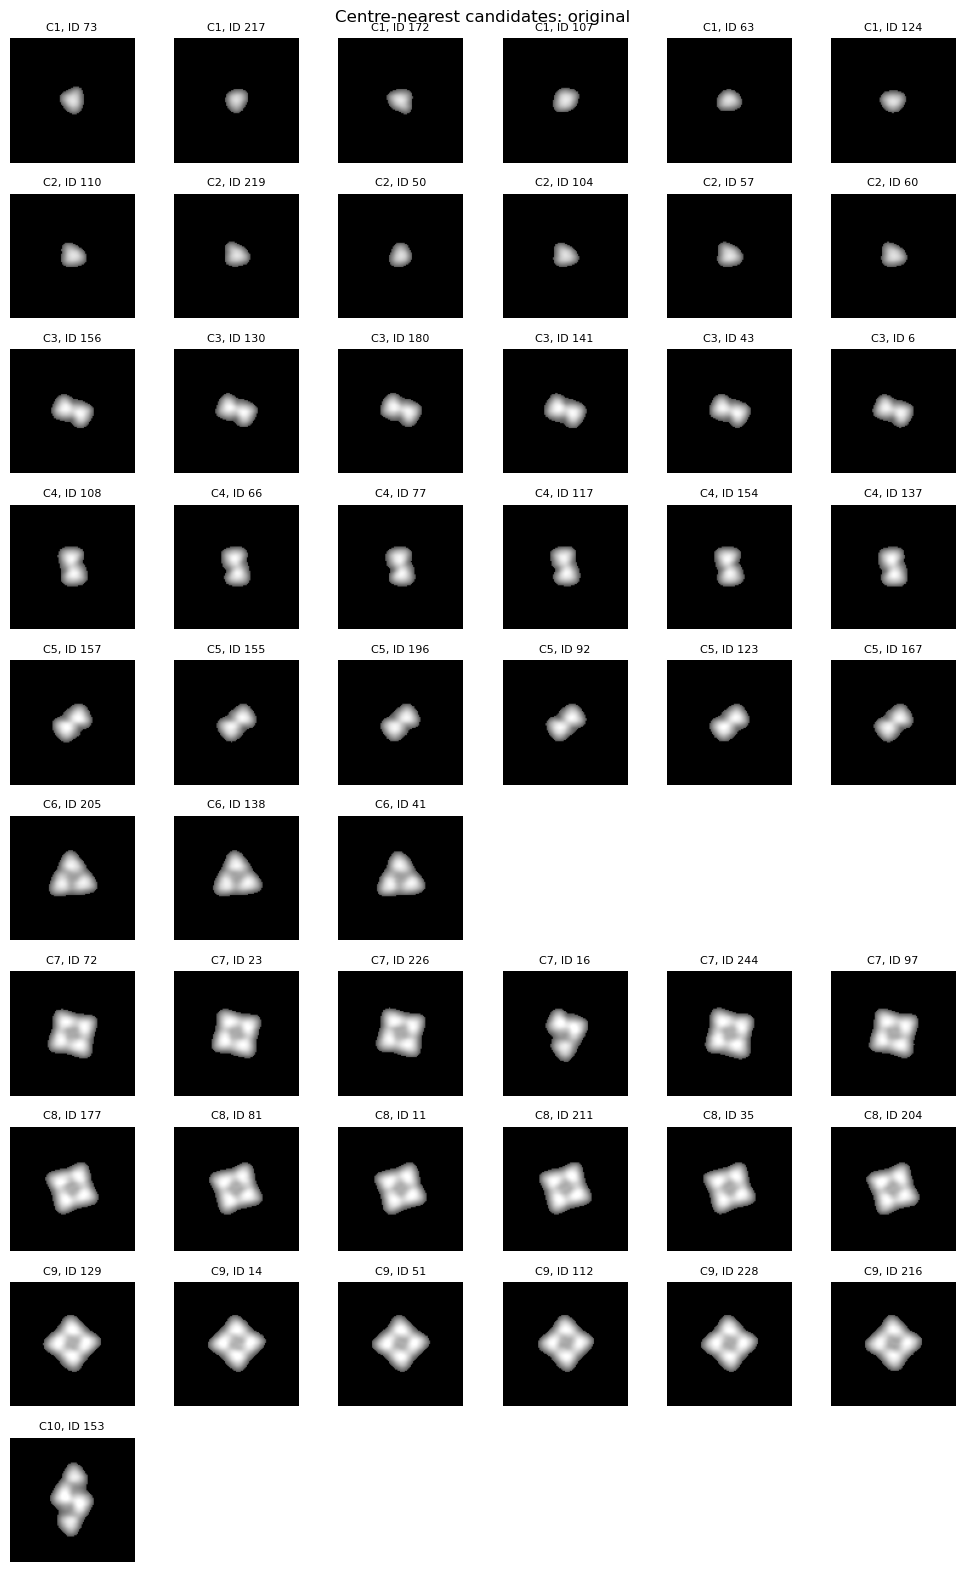

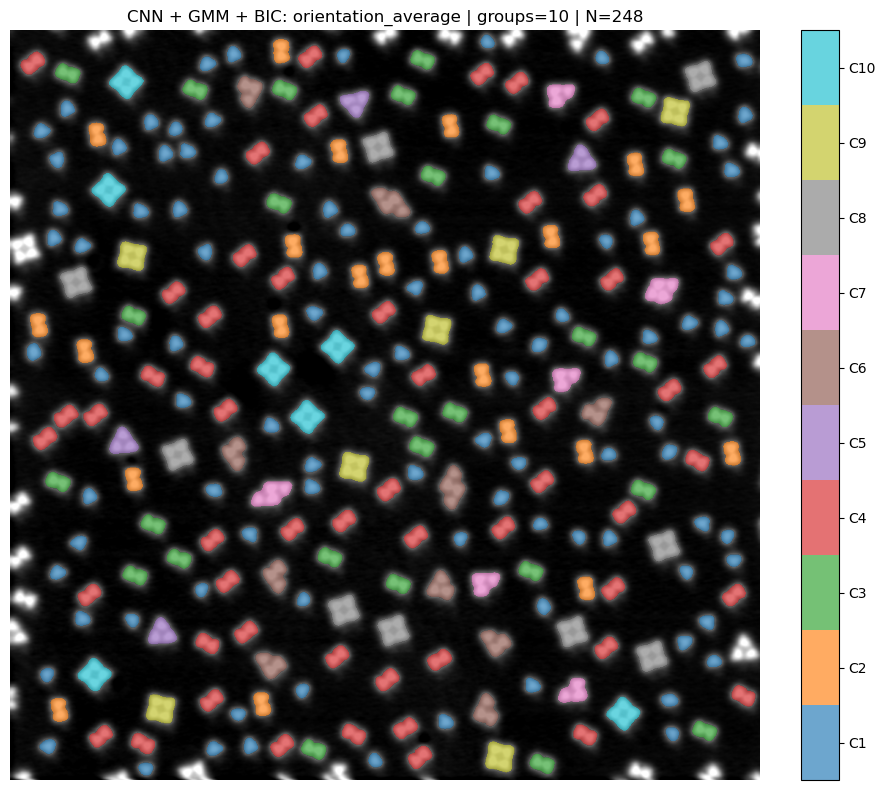

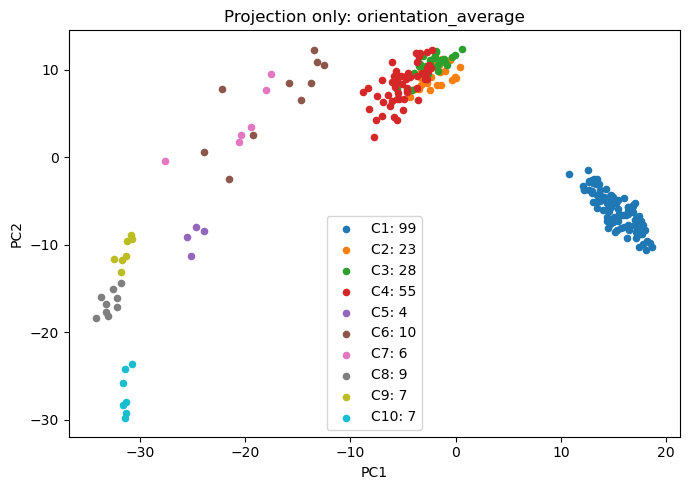

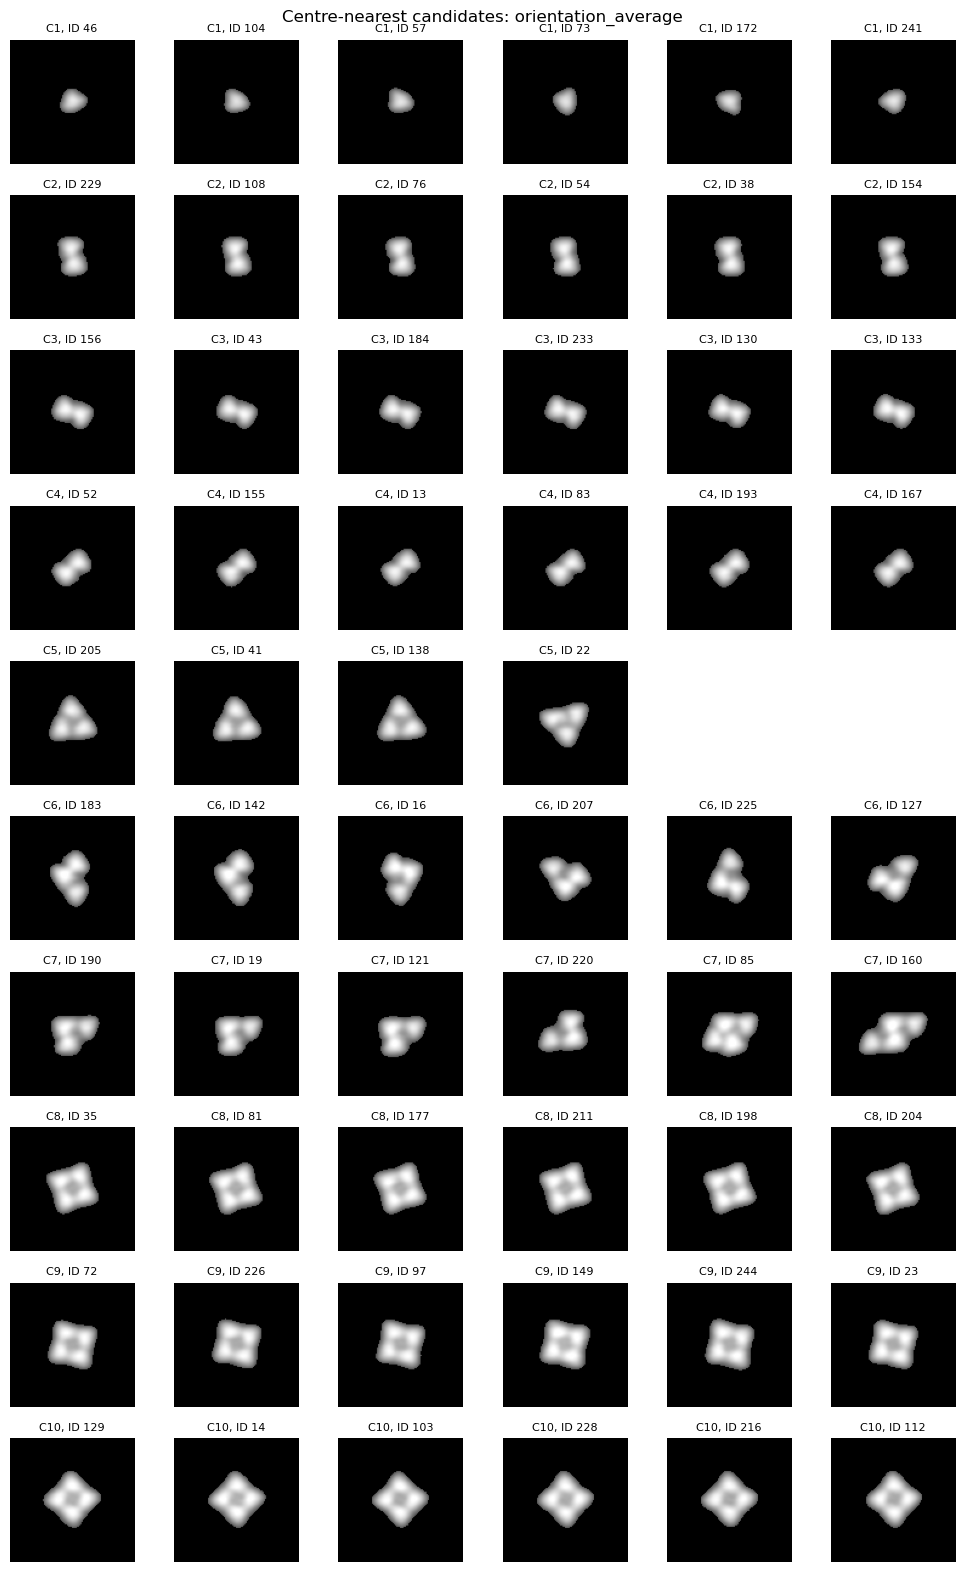

In [4]:
for name, result in results.items():
    k, groups = result["k"], result["groups"]
    colours = list(plt.colormaps["tab10"].colors[:k])
    lookup = np.zeros(int(labels.max())+1, dtype=np.int16)
    lookup[ids] = groups
    group_image = lookup[labels]
    assert np.array_equal(group_image>0, labels>0)
    np.save(OUT/f"{name}_cluster_image.npy", group_image)
    fig, ax = plt.subplots(figsize=(9,8))
    low_display, high_display = np.percentile(height,[2,98])
    ax.imshow(height,cmap="gray",vmin=low_display,vmax=high_display)
    overlay = ax.imshow(np.ma.masked_where(group_image==0,group_image),
                        cmap=ListedColormap(colours),vmin=0.5,vmax=k+0.5,alpha=0.65)
    cb = fig.colorbar(overlay,ax=ax,ticks=np.arange(1,k+1),fraction=0.045)
    cb.ax.set_yticklabels([f"C{i}" for i in range(1,k+1)])
    ax.set_title(f"{METHOD_LABEL}: {name} | groups={k} | N={len(ids)}")
    ax.axis("off")
    fig.tight_layout()
    fig.savefig(OUT/f"{name}_classification_overlay.png",dpi=160,bbox_inches="tight")
    plt.show()
    matrix = representations[name]
    fig, ax = plt.subplots(figsize=(7,5))
    for group, colour in enumerate(colours,1):
        mask = groups==group
        ax.scatter(matrix[mask,0],matrix[mask,1] if matrix.shape[1]>1 else np.zeros(mask.sum()),
                   color=colour,s=20,label=f"C{group}: {mask.sum()}")
    ax.set(xlabel="PC1",ylabel="PC2",title=f"Projection only: {name}")
    ax.legend()
    fig.tight_layout()
    fig.savefig(OUT/f"{name}_pca_scatter.png",dpi=160)
    plt.show()
    fig, axes = plt.subplots(k,6,figsize=(10,1.6*k),squeeze=False)
    for group in range(1,k+1):
        members = np.flatnonzero(groups==group)
        centre = matrix[members].mean(axis=0)
        selected = members[np.argsort(np.linalg.norm(matrix[members]-centre,axis=1))[:6]]
        for j, ax in enumerate(axes[group-1]):
            ax.axis("off")
            if j<len(selected):
                i=selected[j]
                ax.imshow(patches[i],cmap="gray",vmin=0,vmax=1)
                ax.set_title(f"C{group}, ID {ids[i]}",fontsize=8)
    fig.suptitle(f"Centre-nearest candidates: {name}")
    fig.tight_layout()
    fig.savefig(OUT/f"{name}_representatives.png",dpi=150,bbox_inches="tight")
    plt.show()


## 5. Validate exports and preserve upstream files

Check row alignment, total counts, generated figures and unchanged P1/P2 input hashes. Save the model-selection settings and results with relative paths.


In [5]:
assert {name:sha256(FEATURE_DIR/name) for name in feature_artifacts}==feature_hashes
assert sha256(manifest_path)==manifest_hash
assert all(sha256(P1_DIR/name)==digest for name,digest in feature_manifest["input_hashes"].items())
for name,result in results.items():
    saved = pd.read_csv(OUT/f"{name}_assignments.csv")
    saved_counts = pd.read_csv(OUT/f"{name}_counts.csv")
    assert np.array_equal(saved.object_id.to_numpy(),ids) and saved.object_id.is_unique
    assert saved_counts.candidate_count.sum()==len(ids)
    assert saved.cluster_id.nunique()==result["k"]
    for suffix in ["classification_overlay.png","pca_scatter.png","representatives.png"]:
        assert (OUT/f"{name}_{suffix}").stat().st_size>0
run_manifest = {
    "method":METHOD_LABEL,"feature_directory":relative(FEATURE_DIR),
    "output_directory":relative(OUT),"cnn_manifest_sha256":manifest_hash,
    "feature_hashes":feature_hashes,"candidate_count":len(ids),
    "molecular_labels_used":False,"cnn_executed":False,
    "pca_variance":PCA_VARIANCE,"k_search_max":K_MAX,"seed":SEED,
    "method_configuration":METHOD_CONFIGURATION,
    "results":json.loads(metrics.to_json(orient="records")),
}
(OUT/"run_manifest.json").write_text(json.dumps(run_manifest,indent=2,allow_nan=False),encoding="utf-8")
print("Validation outputs saved:",relative(OUT))
print("P1 and P2 inputs unchanged. No CNN execution was needed.")
display(metrics)


Validation outputs saved: Notebooks/P3/outputs/cnn_gmm_bic
P1 and P2 inputs unchanged. No CNN execution was needed.


,representation,candidate_count,pca_dimensions,selected_components,nonempty_groups,covariance_type,bic,aic,silhouette,at_search_upper_limit,near_best_models_delta_bic_under_2
0,original,248,39,10,10,diag,37065.356999,34293.261719,0.277762,True,1
1,orientation_average,248,15,10,10,tied,15254.980995,14274.734375,0.515110,True,1
